# **********************************Stock Data Prediction System**********************************

In [ ]:
#Step 1: Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Download Dataset from : https://www.kaggle.com/code/siddhvr/eda-of-stock-prices-of-maang-companies/input

#Step 2: Load the dataset:
df = pd.read_csv(r"C:\Users\EXAM_USER\Downloads\Stock_Price.csv", index_col=0) #Replace with actual dataset file 

In [ ]:
# Step 3: Data Inspection
 #Displays first few rows

(df.head()) 

,High,Low,Close,Adj Close,Volume,Date
Open,,,,,,
4.075000,4.478125,3.952344,4.468750,4.468750,322352000,2000-01-03
4.268750,4.575000,4.087500,4.096875,4.096875,349748000,2000-01-04
3.525000,3.756250,3.400000,3.487500,3.487500,769148000,2000-01-05
3.565625,3.634375,3.200000,3.278125,3.278125,375040000,2000-01-06
3.350000,3.525000,3.309375,3.478125,3.478125,210108000,2000-01-07


In [ ]:
#Check data types and missing values 

print(df.info()) 


<class 'pandas.core.frame.DataFrame'>
Index: 5839 entries, 4.074999809265137 to 99.79000091552734
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       5839 non-null   float64
 1   Low        5839 non-null   float64
 2   Close      5839 non-null   float64
 3   Adj Close  5839 non-null   float64
 4   Volume     5839 non-null   int64  
 5   Date       5839 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 319.3+ KB
None


In [ ]:
#Summary statistics

(df.describe())

,High,Low,Close,Adj Close,Volume
count,5839.000000,5839.000000,5839.000000,5839.000000,5.839000e+03
mean,35.280858,34.410312,34.853440,34.853440,1.239786e+08
std,50.162208,48.924149,49.540404,49.540404,9.910548e+07
min,0.305000,0.275500,0.298500,0.298500,1.762600e+07
25%,2.252750,2.175000,2.221500,2.221500,6.798200e+07
50%,9.570000,9.285500,9.437500,9.437500,1.015480e+08
75%,48.138500,47.507500,47.833000,47.833000,1.479700e+08
max,188.654007,184.839493,186.570496,186.570496,2.086584e+09


In [ ]:
#Show Columns

print(df.columns)

Index(['High', 'Low', 'Close', 'Adj Close', 'Volume', 'Date'], dtype='object')


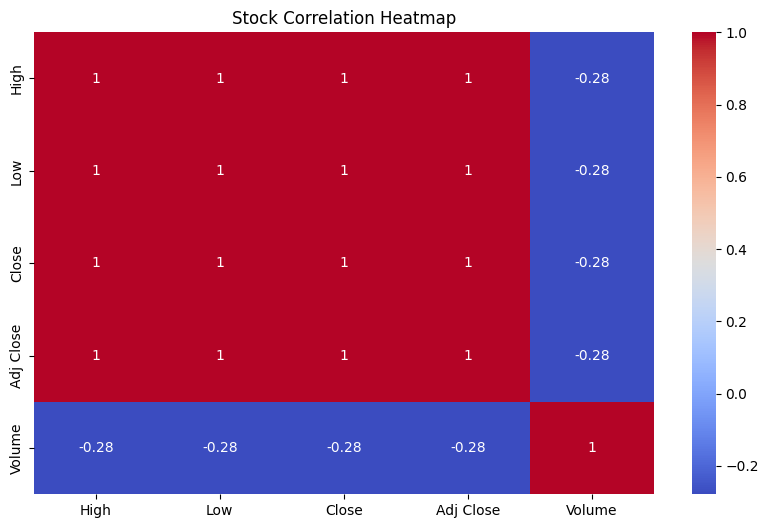

In [ ]:
# Step 4: Exploratory Data Analysis (EDA)

plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap = 'coolwarm')

plt.title("Stock Correlation Heatmap")

plt.show()

In [ ]:
# Step 5: Data Preprocessing
#Selecting features and target variable

X = df[['High','Adj Close',]]
y = df['Volume']

In [ ]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 6: Model Training
model = LinearRegression()
model.fit (X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Step 7: Model Prediction
y_pred = model.predict(X_test)


In [ ]:
# Step 8: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error:, {mse}")
print(f"Mean Squared Error: {mse}")
print(f"R- squared Score:, {r2}")


Mean Absolute Error:, 7749619912697114.0
Mean Squared Error: 7749619912697114.0
R- squared Score:, 0.11280257189302634


In [ ]:
# Predicted Table of Actual & Predicted Price

predicted = model.predict(X_test)
dfr = pd.DataFrame({'Actual_Price':y_test,'Predicted_Price':predicted})
print(dfr)

           Actual_Price  Predicted_Price
Open                                    
79.322502      95016000     9.183342e+07
2.209375      139270000     1.417519e+08
2.118750      258392000     1.417568e+08
15.147500      64690000     1.318995e+08
4.066500      323754000     1.407019e+08
...                 ...              ...
92.050003      59990000     9.013201e+07
1.995500      214236000     1.422404e+08
3.796500      113060000     1.399294e+08
94.162498      80854000     9.673356e+07
1.924500      132226000     1.417742e+08

[1168 rows x 2 columns]


In [ ]:
dfr.describe()

,Actual_Price,Predicted_Price
count,1.168000e+03,1.168000e+03
mean,1.258486e+08,1.239926e+08
std,9.350096e+07,2.881318e+07
min,2.746000e+07,1.810990e+07
25%,6.915818e+07,1.172874e+08
50%,1.038320e+08,1.385951e+08
75%,1.507360e+08,1.415754e+08
max,1.243590e+09,1.962319e+08


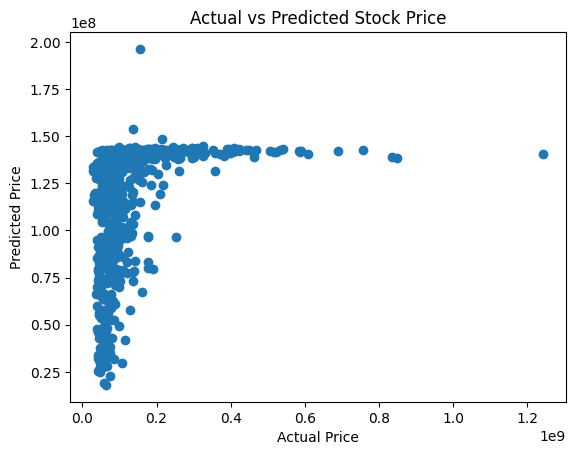

In [ ]:
# Step 9: Visualization of Predictions 

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Stock Price")
plt.show()

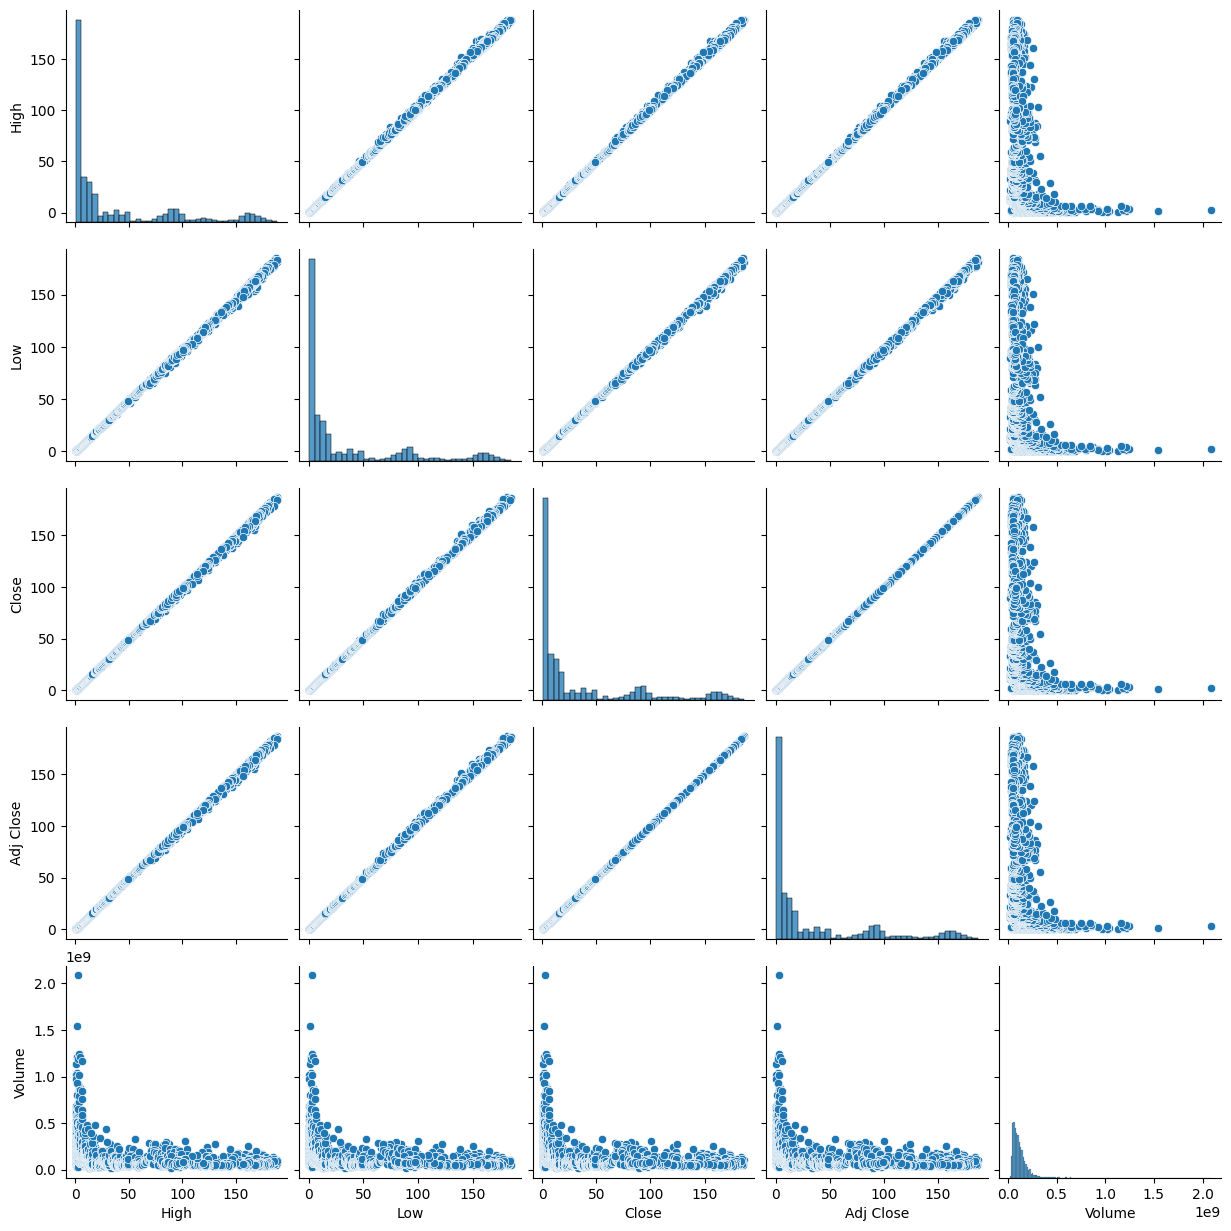

In [ ]:
#Showing visualization on all variables in the data
sns.pairplot(df)

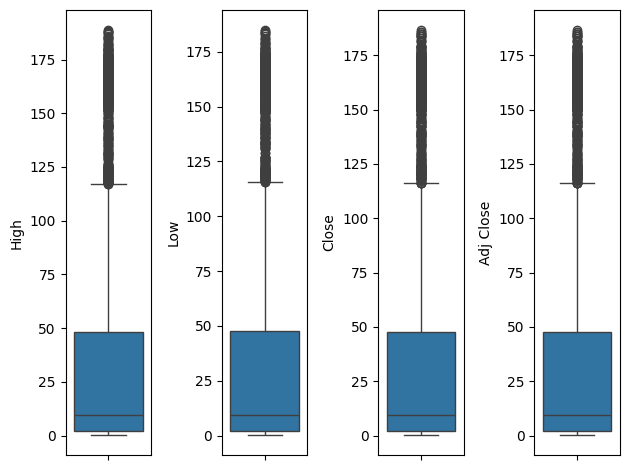

In [ ]:
#Review box plots
f, axes = plt.subplots(1, 4)
sns.boxplot( y ='High', data=df, ax=axes[0])
sns.boxplot( y ='Low', data=df, ax=axes[1])
sns.boxplot( y ='Close', data=df, ax=axes[2])
sns.boxplot( y ='Adj Close', data=df, ax=axes[3])
plt.tight_layout()